# 30 — `kde`

`Map.kde` estimates a **continuous density surface** by summing a smooth kernel over every point. It answers
"where is this concentrated?" without imposing a grid, so there are no cell edges and no `gridsize` to defend —
the trade is that the smoothing bandwidth becomes the thing you have to justify instead.

By the end you will be able to draw a density surface from a point collection and clip it to a study area.

API: [`Map.kde`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832


## The data

The 3,000 GBIF bird records, in a metric CRS so the kernel is isotropic.

In [2]:
birds = FeatureCollection.read_file(str(DATA / "heidelberg_birds_2023.geojson"))
print(f"{len(birds)} bird records, {birds['species'].nunique()} species, EPSG:{birds.crs.to_epsg()}")
birds[["species", "eventDate", "uncertainty_m"]].head()

3000 bird records, 111 species, EPSG:4326


,species,eventDate,uncertainty_m
0,Corvus corone,2023-01-11 12:27:25+00:00,NaN
1,Cyanistes caeruleus,2023-01-11 15:49:00+00:00,8.0
2,Phalacrocorax carbo,2023-01-11 11:58:48+00:00,NaN
3,Cyanistes caeruleus,2023-01-11 15:49:04+00:00,8.0
4,Alopochen aegyptiaca,2023-01-11 11:56:46+00:00,NaN


## Quickstart — the density surface

`kde` needs only the points. It draws filled density contours, each band enclosing a share of the estimated
density.

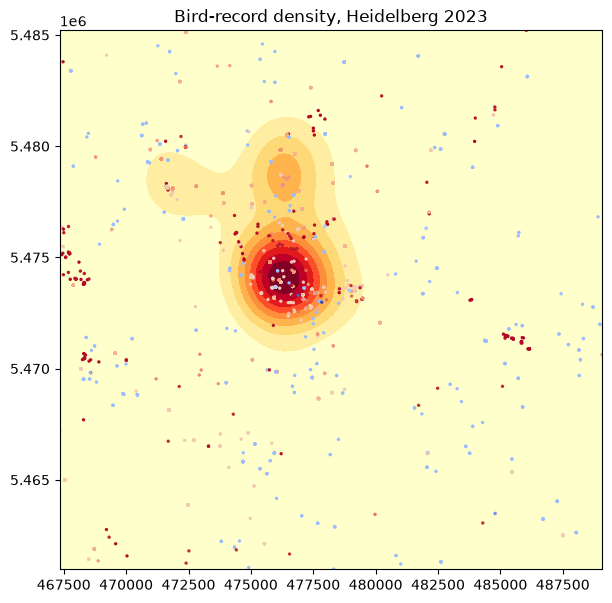

In [3]:
m = Map(crs=UTM32, figsize=(7, 7))
m.kde(birds, cmap="YlOrRd")
m.points(birds, size=2)
m.set_title("Bird-record density, Heidelberg 2023")
m.fig;

The peak is over the city and the ridge follows the Neckar. Compare it with the hexbin count map: the same
signal, but the kernel smooths across cell boundaries, so the valley reads as one continuous corridor rather
than a chain of cells.

Be careful what you claim from it. This is the density of **observations**, not of birds — a KDE of volunteer
records maps the observers. The bright core is where people live and walk, and reading it as abundance is the
single most common misuse of occurrence data.

## Clipping to a study area

The surface spreads past the data, so like `voronoi` it needs bounding. `clip=` trims it to a boundary.

| argument | meaning | typical value |
|---|---|---|
| `features` | the point collection to estimate from | a point `FeatureCollection` |
| `clip` | polygons to trim the surface to | a polygon `FeatureCollection` |

In [4]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
bw = FeatureCollection(states[states["shapeName"] == "Baden-Württemberg"])
print("clipping to:", bw["shapeName"].iloc[0])

clipping to: Baden-Württemberg


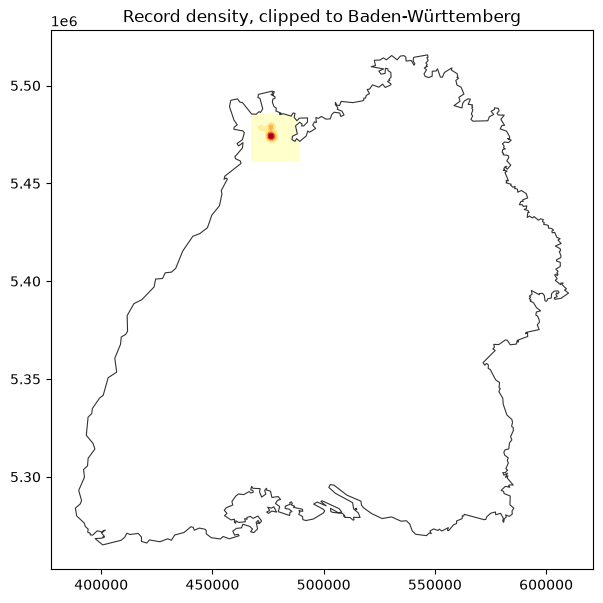

In [5]:
m = Map(crs=UTM32, figsize=(7, 7))
m.kde(birds, clip=bw, cmap="YlOrRd")
m.polygons(bw, edgecolor="#333333", linewidth=0.8)
m.set_title("Record density, clipped to Baden-Württemberg")
m.fig;

Clipped, the figure reads as a regional map: one dense recording core around Heidelberg, fading north-east along
the valley, with the rest of the state effectively unrecorded in this slice. That emptiness is a real finding
about the data, and the unclipped version hid it by letting the kernel spread into space it had no evidence
for.

## Takeaway

- `kde(points)` gives a **smooth** density surface — no grid, no cell edges.
- The smoothing is a modelling choice: it invents structure between points, so say what it is a density *of*.
- `clip=` keeps the claim inside the study area and exposes where the data runs out.
- Use `kde` to show *where things concentrate*, and `hexbin`/`quadtree` when a reader needs per-cell numbers.

Next: [`31_cartogram`](31_cartogram.ipynb) distorts polygon geometry by a value instead of colouring it.